# 2. Hafta - Belirme ve Hücresel Otomatların Sınıflandırılması

Proje: Hücresel Otomatlarda Beliren Karmaşıklık  
Not defteri: `02_rule_classification.ipynb`  
Tahmini süre: 8–10 saat

Geçen hafta dört temel hücresel otomatı sıfırdan oluşturup karşılaştırdım. Bu hafta dört örnekten 256 kuralın sistematik incelenmesine geçiyorum.

Ana araştırma sorumuz:

> Hücresel otomatları büyük ölçekli davranışlarına göre sınıflandırabilir miyiz ve sayısal ölçümler resimlerin söylemediği neyi gösterebilir?

Bu hafta önemli bir bilimsel alışkanlık geliştireceğim: önce gözlem yapacak, sonra sınıflandırma ölçütlerimi açıkça yazacak ve en son ölçümlerle öngörülerimin doğruluğunu test edeceğim.

## Öğrenme hedefleri

Bu not defterinin sonunda şunları yapabilmeliyim:

1. aynı başlangıç koşulundan 256 ECA kuralını üretmek,
2. tekrarlanabilir rastgele başlangıç koşulları oluşturmak,
3. Wolfram'ın dört nitel sınıfını örneklerle açıklamak,
4. yoğunluk $\rho(t)$ ve etkinlik $a(t)$ ölçümlerini hesaplamak,
5. bir görsel sınıflandırmayı ölçülebilir kanıtlarla savunmak,
6. bir kuralın görünüşünün başlangıç koşuluna bağlı olabileceğini göstermek.

### Bilimsel iş akışı

$$
\boxed{\text{Soru} \rightarrow \text{Deney protokolü} \rightarrow
\text{Gözlem} \rightarrow \text{Ölçüm} \rightarrow \text{Yorum}}
$$

Bu sıralamada özellikle gözlem ile yorum arasındaki farkı koru. “Kural 30'un 80 satırının 80'i farklıdır” bir gözlemdir. “Kural 30 kaotiktir” ise gözlemlere dayanan bir yorumdur.

### Başlamadan önce: tahminlerini kaydet

Kodları çalıştırmadan önce kısa yanıtlar yaz:

1. 256 kuralın çoğunun düzenli mi, yoksa karmaşık mı olmasını bekliyorsun? Neden?
2. Tek dolu hücre ve rastgele bir satır aynı kural için aynı sınıflandırmayı verir mi?
3. Bir desenin kaotik olduğunu yalnızca resmine bakarak söylemek güvenilir midir?

Tahminlerim:

> 1. Kuralların çoğunun *düzenli* (Sınıf I veya II) olmasını bekliyorum, çünkü 8 çıktı bitini rastgele seçtiğimizde çoğu kombinasyonun ya çok az 1 içerip hızla sönmesi ya da basit bir simetriye sahip olup periyodik bir örüntüye kilitlenmesi daha olası görünüyor.
> 2. Hayır, aynı sınıflandırmayı vermeyebilir. Tek dolu hücre çok özel, simetrik bir başlangıç; rastgele başlangıç farklı komşulukların hepsini bir arada sunuyor, bu yüzden görünüm değişebilir.
> 3. Hayır, tam olarak güvenilir değildir. Sonlu bir resim sonsuz zaman davranışını kanıtlamaz, bu yüzden görsel izlenimi sayısal ölçümlerle birlikte kullanmak gerekiyor.

<details>
<summary>Düşünme ipucu</summary>

Bu soruların tek bir hazır yanıtı yoktur. Önemli olan tahminini deneyden önce kaydetmek ve deneyden sonra neyin değiştiğini açıklamaktır.
</details>


In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["image.cmap"] = "binary"


def check(label, test_function):
    '''Bir öğrenci testini not defterini durdurmadan çalıştır.'''
    try:
        test_function()
    except (AssertionError, NotImplementedError) as error:
        message = str(error) or "sonuç beklenen değerle eşleşmedi"
        print(f"○ {label}: çalışmaya devam et — {message}")
    else:
        print(f"✓ {label}: geçti")


print("Kurulum tamamlandı.")

Kurulum tamamlandı.


## 1. Geçen haftanın benzetim motoru

Aşağıdaki motor, 1. haftada yazdığım kodla aynı fiziksel modeli uygular. Bu hafta hedefim motoru yeniden yazmak değil, onu bir deney aracı olarak kullanmaktır.

Kural numarasının `index` numaralı bitini

```python
(rule_number >> index) & 1
```

ifadesiyle okuyoruz. `np.roll`, periyodik sınır koşullarında sol ve sağ komşuları buluyor.

In [2]:
def update_row(row, rule_number):
    '''Periyodik sınırlı bir ECA satırını bir zaman adımı ilerlet.'''
    row = np.asarray(row, dtype=np.uint8)
    left = np.roll(row, 1)
    right = np.roll(row, -1)
    indices = 4 * left + 2 * row + right
    return ((int(rule_number) >> indices) & 1).astype(np.uint8)


def simulate(initial_row, rule_number, steps):
    '''Başlangıç satırı dâhil olmak üzere uzay-zaman geçmişini döndür.'''
    initial_row = np.asarray(initial_row, dtype=np.uint8)
    history = np.zeros((steps, len(initial_row)), dtype=np.uint8)
    history[0] = initial_row
    for t in range(1, steps):
        history[t] = update_row(history[t - 1], rule_number)
    return history


def single_seed(width):
    '''Ortası dolu, diğer hücreleri boş bir satır oluştur.'''
    state = np.zeros(width, dtype=np.uint8)
    state[width // 2] = 1
    return state


assert simulate(single_seed(9), 90, 5).shape == (5, 9)
print("Benzetim motoru hazır.")

Benzetim motoru hazır.


## 2. Tekrarlanabilir rastgele başlangıç koşulu

Bir hücrenin başlangıçta dolu olma olasılığına $p$ diyelim:

$$
P(s_i(0)=1)=p.
$$

Rastgele deneyler yaparken aynı sonucu yeniden üretebilmek için bir rastgele sayı üreteci (`rng`) kullanacağız:

```python
rng = np.random.default_rng(42)
```

Aynı tohum (`42`) aynı sayı dizisini üretir. Bu, hesaplamalı bilimin tekrarlanabilirlik ilkesidir.

### Alıştırma 1

`random_initial_state` fonksiyonunu tamamla. `rng.random(width)` ile $[0,1)$ aralığında sayılar üret; her sayının `density` değerinden küçük olup olmadığını karşılaştır. Sonucu `np.uint8` türüne dönüştür.

In [3]:
def random_initial_state(width, density, rng):
    '''Yaklasik verilen yogunlukta rastgele 0/1 satiri olustur.'''
    return (rng.random(width) < density).astype(np.uint8)


In [4]:
def test_random_initial_state():
    a = random_initial_state(100, 0.35, np.random.default_rng(123))
    b = random_initial_state(100, 0.35, np.random.default_rng(123))
    assert a.shape == (100,), f"beklenen biçim (100,), bulunan {a.shape}"
    assert set(np.unique(a)) <= {0, 1}, "durum yalnızca 0 ve 1 içermeli"
    assert np.array_equal(a, b), "aynı tohum aynı satırı üretmeli"
    assert random_initial_state(20, 0.0, np.random.default_rng(1)).sum() == 0, (
        "p=0 iken bütün hücreler boş olmalı"
    )
    assert random_initial_state(20, 1.0, np.random.default_rng(1)).sum() == 20, (
        "p=1 iken bütün hücreler dolu olmalı"
    )


check("Alıştırma 1 — rastgele başlangıç", test_random_initial_state)

✓ Alıştırma 1 — rastgele başlangıç: geçti


### Referans başlangıç fonksiyonu

Galerinin, alıştırman tamamlanmadan da çalışabilmesi için aşağıdaki referans fonksiyonu kullanılacaktır. Testin geçtikten sonra iki fonksiyonun aynı tohumla aynı sonucu verdiğini kontrol et.

In [5]:
def _random_initial_state_reference(width, density, rng):
    return (rng.random(width) < density).astype(np.uint8)

## 3. Wolfram'ın nitel sınıfları

Stephen Wolfram, ECA davranışlarını kabaca dört grupta ele almıştır:

| Sınıf | Tipik uzun-zaman davranışı | Görsel ipuçları |
|---:|---|---|
| I | Homojen duruma yaklaşır | Tamamen boş veya tamamen dolu hâle gelme |
| II | Sabit ya da periyodik yapılar | Tekrarlanan satırlar, çizgiler, küçük salınımlar |
| III | Kaotik görünümlü davranış | Düzensiz doku, uzun süre devam eden değişim |
| IV | Karmaşık ve yerel yapılar | Düzenli arka plan üzerinde etkileşen/hareket eden yapılar |

Bu tablo kesin bir otomatik algoritma değildir. Sonlu bir resim, sonsuz-zaman davranışını kanıtlamaz. Ayrıca farklı başlangıç koşulları aynı kuralın farklı özelliklerini gösterebilir.

<details>
<summary>Soru: “61 satırın 61'i farklı” olması tek başına Sınıf III'ü kanıtlar mı?</summary>

Hayır. Uzun geçici davranış gösteren Sınıf IV benzeri bir kuralda da bütün satırlar farklı olabilir. Tek bir ölçümü kesin bir etiket olarak değil, bir kanıt parçası olarak kullanmalıyız.
</details>

<details>
<summary>Soru: Neden sınıflandırma yapmadan önce başlangıç koşulunu belirtmeliyiz?</summary>

Çünkü gözlediğimiz dinamik hem kurala hem başlangıç durumuna bağlıdır. Örneğin bütün hücreleri boş bir başlangıç, birçok ilginç kural için tamamen boş kalabilir ve kuralın zengin davranışını gizleyebilir.
</details>

## 4. 256 kuralın galerisi

Adil bir karşılaştırma için bütün kurallarda şu değişkenleri sabit tutacağız:

- genişlik: 101 hücre,
- süre: 80 zaman adımı,
- başlangıç yoğunluğu: $p=0.5$,
- rastgele tohum: 42,
- sınır koşulu: periyodik.

Burada aynı başlangıç satırını bütün kurallara veriyoruz. Böylece değişen tek şey kural numarası oluyor.

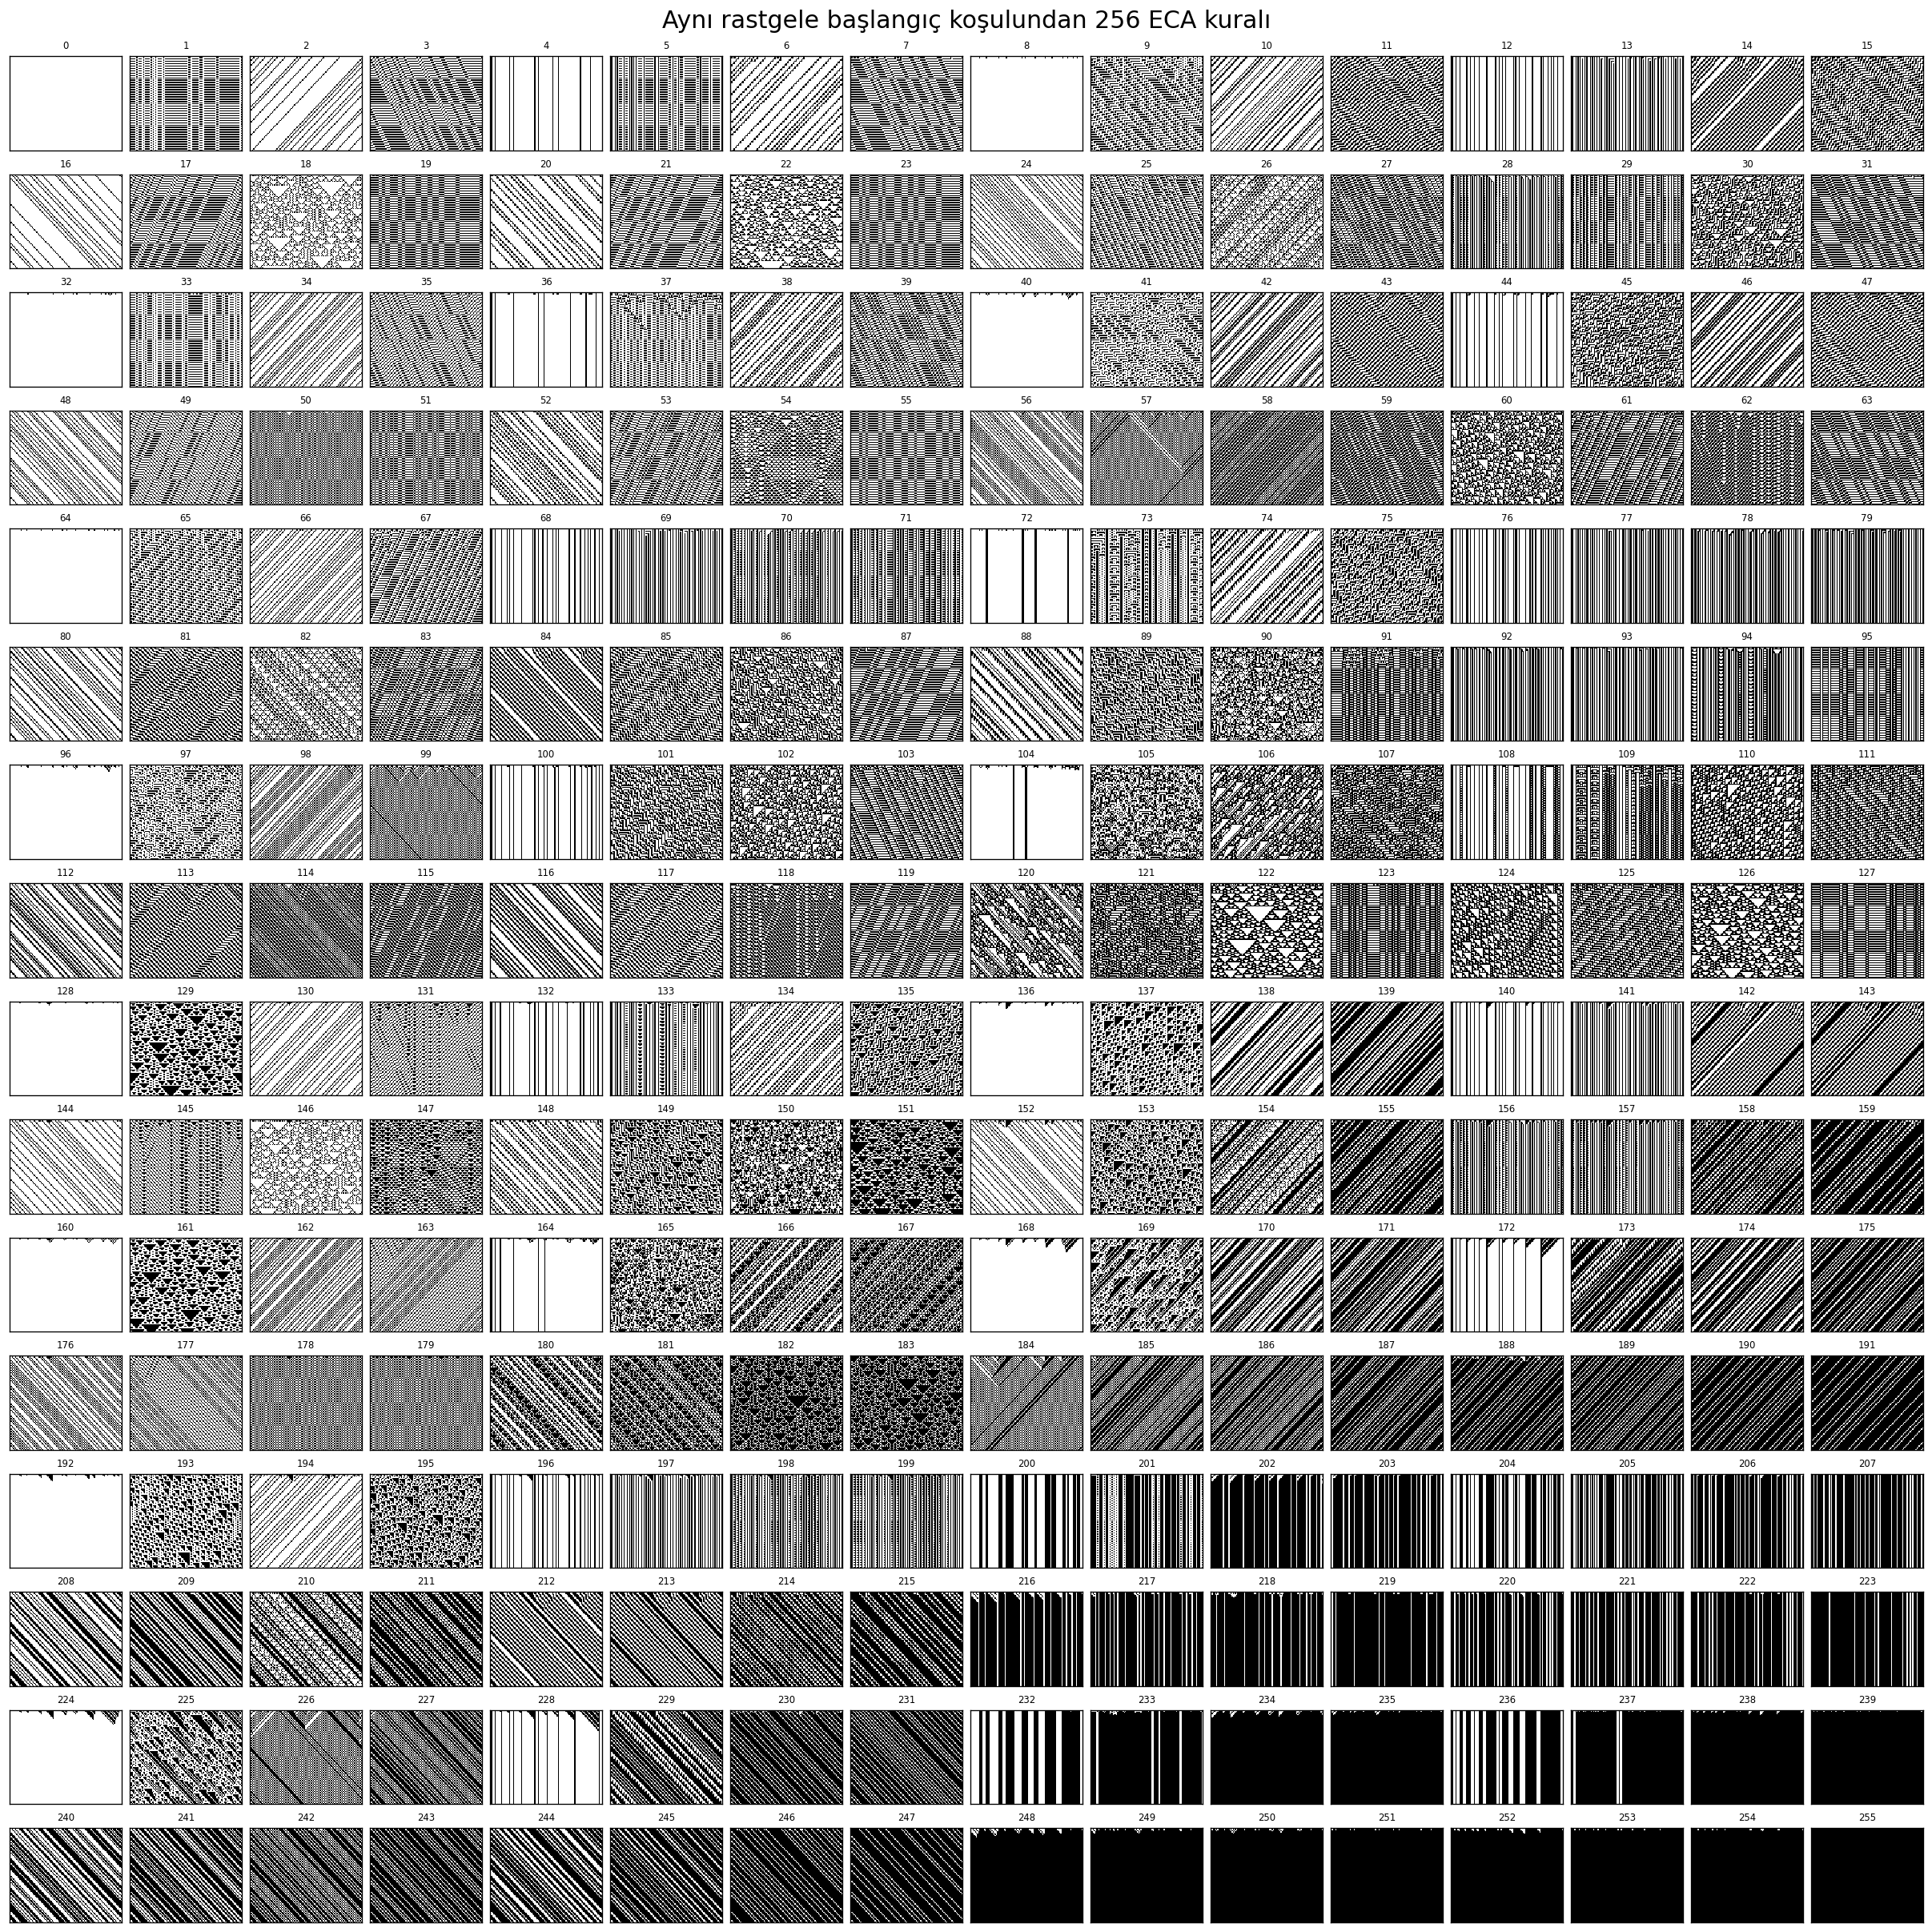

In [6]:
gallery_width = 101
gallery_steps = 80
gallery_density = 0.5

gallery_initial = _random_initial_state_reference(
    gallery_width, gallery_density, np.random.default_rng(42)
)

fig, axes = plt.subplots(16, 16, figsize=(20, 20), constrained_layout=True)

for rule, ax in enumerate(axes.flat):
    history = simulate(gallery_initial, rule, gallery_steps)
    ax.imshow(history, interpolation="nearest", aspect="auto", vmin=0, vmax=1)
    ax.set_title(str(rule), fontsize=7)
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle("Aynı rastgele başlangıç koşulundan 256 ECA kuralı", fontsize=18)
plt.show()

### Galeri gözlemi

Galeriyi büyüterek incele ve aşağıdakileri doldur:

- Hızla homojenleşen üç kural: `0, 8, 32`
- Açıkça tekrarlanan desen gösteren üç kural: `4, 12, 94`
- Düzensiz görünen üç kural: `30, 45, 60`
- Sınıflandırmakta en çok zorlandığım üç kural: `54, 73, 184`

İlk gözlem notlarım:

> Kural 0, 8 ve 32'de galeri neredeyse tamamen boş/beyaz görünüyor.
>
> Kural 94'te galeri, sabit genişlikte dikey şeritler gösteriyor; donuk/düzenli bir izlenim veriyor. Kural 4 ve 12'de de benzer şekilde birkaç dikey çizgiye kilitlenmiş bir görüntü var.
>
> Kural 30, 45 ve 60 galeri karesinde düzensiz, tekrarsız görünen bir doku dolduruyor.
>
> En çok zorlandığım kurallar Kural 54, 73 ve 184 oldu: görüntü ne tamamen donuk ne de tamamen gürültülü. Kesin bir etiket koymuyorum. Asıl sınıflandırmayı ikinci yarıda yoğunluk/etkinlik ölçümleriyle birlikte yapacağız.

<details>
<summary>Kontrol sorusu: Galerideki 256 küçük resmi ayrı deneyler olarak düşünebilir miyiz?</summary>

Evet. Ancak kontrollü deneylerdir. Başlangıç durumu, genişlik, süre ve sınır koşulu aynıdır. Yalnızca kural numarası değiştirilmiştir.
</details>


## 5. İlk gözlenebilir: yoğunluk

Bir satırdaki dolu hücrelerin oranına yoğunluk diyoruz:

$$
\rho(t)=\frac{1}{N}\sum_{i=1}^{N}s_i(t).
$$

`history` dizisinin her satırı bir zamanı temsil ettiği için, her satırın ortalamasını almalıyız.

### Alıştırma 2

`density_time_series` fonksiyonunu tamamla. Sonucun uzunluğu zaman adımı sayısına eşit olmalı.

### Yoğunluğun anlamı

$\rho(t)$, o zaman adımındaki satırda **1 durumundaki hücrelerin oranını** ölçer, bu yüzden her zaman $0 \le \rho(t) \le 1$ aralığındadır. Yüksek $\rho(t)$ daha çok dolu (1) hücre, düşük $\rho(t)$ daha çok boş (0) hücre anlamına gelir.

Yoğunluk tek başına **uzamsal düzeni** söylemez: hücrelerin nerede olduğunu, kümelenip kümelenmediğini veya bir desenin tekrarlı mı yoksa düzensiz mi olduğunu göstermez. Aynı $\rho(t)$ değerine sahip iki satır, örneğin hücreler eşit aralıklarla yayılmışken ya da tek bir blokta toplanmışken, tamamen farklı görsel desenlere karşılık gelebilir. Bu yüzden yoğunluğu tek başına bir sınıflandırma ölçütü olarak kullanmayacağız, aşağıdaki etkinlik ölçümüyle birlikte değerlendireceğiz.


In [7]:
def density_time_series(history):
    '''Her zaman adımındaki dolu hücre oranını döndür.'''
    history = np.asarray(history)
    return history.mean(axis=1)


In [8]:
def test_density_time_series():
    example = np.array([
        [0, 0, 0, 0],
        [1, 0, 0, 0],
        [1, 0, 1, 0],
        [1, 1, 1, 1],
    ])
    result = density_time_series(example)
    expected = np.array([0.0, 0.25, 0.5, 1.0])
    assert result.shape == (4,), f"beklenen biçim (4,), bulunan {result.shape}"
    assert np.allclose(result, expected), f"beklenen {expected}, bulunan {result}"


check("Alıştırma 2 - yoğunluk", test_density_time_series)

✓ Alıştırma 2 - yoğunluk: geçti


## 6. İkinci gözlenebilir: etkinlik

Yoğunluk, hücrelerin nerede olduğunu veya zaman içinde değişip değişmediğini söylemez. Bu nedenle ardışık iki satır arasında değişen hücrelerin oranını ölçelim:

$$
a(t)=\frac{1}{N}\sum_{i=1}^{N}|s_i(t+1)-s_i(t)|.
$$

- $a(t)=0$: hiçbir hücre değişmemiştir;
- $a(t)=1$: her hücre durum değiştirmiştir.

`np.diff(history, axis=0)` ardışık satırların farkını verir. Fakat `uint8` türünde negatif sayılar taşabileceği için önce diziyi işaretli tam sayıya dönüştür.

### Alıştırma 3

`activity_time_series` fonksiyonunu tamamla. Sonucun uzunluğu `steps - 1` olacaktır.

Etkinlik, yoğunluğun göremediği bir şeyi ölçer: hücrelerin gerçekte zaman içinde değişip değişmediğini. Ama **yüksek etkinlik otomatik olarak kaos anlamına gelmez**  Düzenli biçimde kayan ya da periyodik olarak salınan bir desen de sürekli yüksek etkinlik üretebilir (aşağıda Kural 184'te tam olarak bunu göreceğiz: etkinliği neredeyse sabit ve çok yüksek, ama davranışı kaotik değil, deterministik bir kaymadır). Bu yüzden etkinliği de görsel gözlemle birlikte yorumlamak gerekiyor.


In [9]:
def activity_time_series(history):
    '''Ardışık zamanlarda değişen hücrelerin oranını döndür.'''
    history = np.asarray(history, dtype=int)
    return np.abs(np.diff(history, axis=0)).mean(axis=1)


In [10]:
def test_activity_time_series():
    example = np.array([
        [0, 0, 0, 0],
        [1, 0, 0, 0],
        [1, 0, 1, 0],
        [0, 1, 0, 1],
    ], dtype=np.uint8)
    result = activity_time_series(example)
    expected = np.array([0.25, 0.25, 1.0])
    assert result.shape == (3,), f"beklenen biçim (3,), bulunan {result.shape}"
    assert np.allclose(result, expected), f"beklenen {expected}, bulunan {result}"


check("Alıştırma 3 - etkinlik", test_activity_time_series)

✓ Alıştırma 3 - etkinlik: geçti


### Ölçümler için referans fonksiyonları

Sonraki karşılaştırma şekli, alıştırmalar bitmeden de çalışabilmesi için referans fonksiyonlarını kullanır. Testlerin geçtikten sonra aşağıdaki fonksiyonları kendi fonksiyonlarınla değiştirip şeklin aynı kaldığını kontrol et.

In [11]:
def _density_reference(history):
    return np.asarray(history).mean(axis=1)


def _activity_reference(history):
    signed = np.asarray(history, dtype=int)
    return np.abs(np.diff(signed, axis=0)).mean(axis=1)

## 7. Aynı yoğunluk, farklı dinamik

Aşağıda farklı davranış türlerinden sekiz kuralı aynı başlangıç koşuluyla karşılaştırıyoruz:

```python
[0, 4, 30, 54, 90, 110, 126, 184]
```

Üst panel yoğunluğu, alt panel etkinliği gösterir. Eğrileri çizmeden önce şu tahmini yap:

> Hangi kuralların uzun zaman etkinliğinin sıfıra yaklaşmasını bekliyorum ve neden?

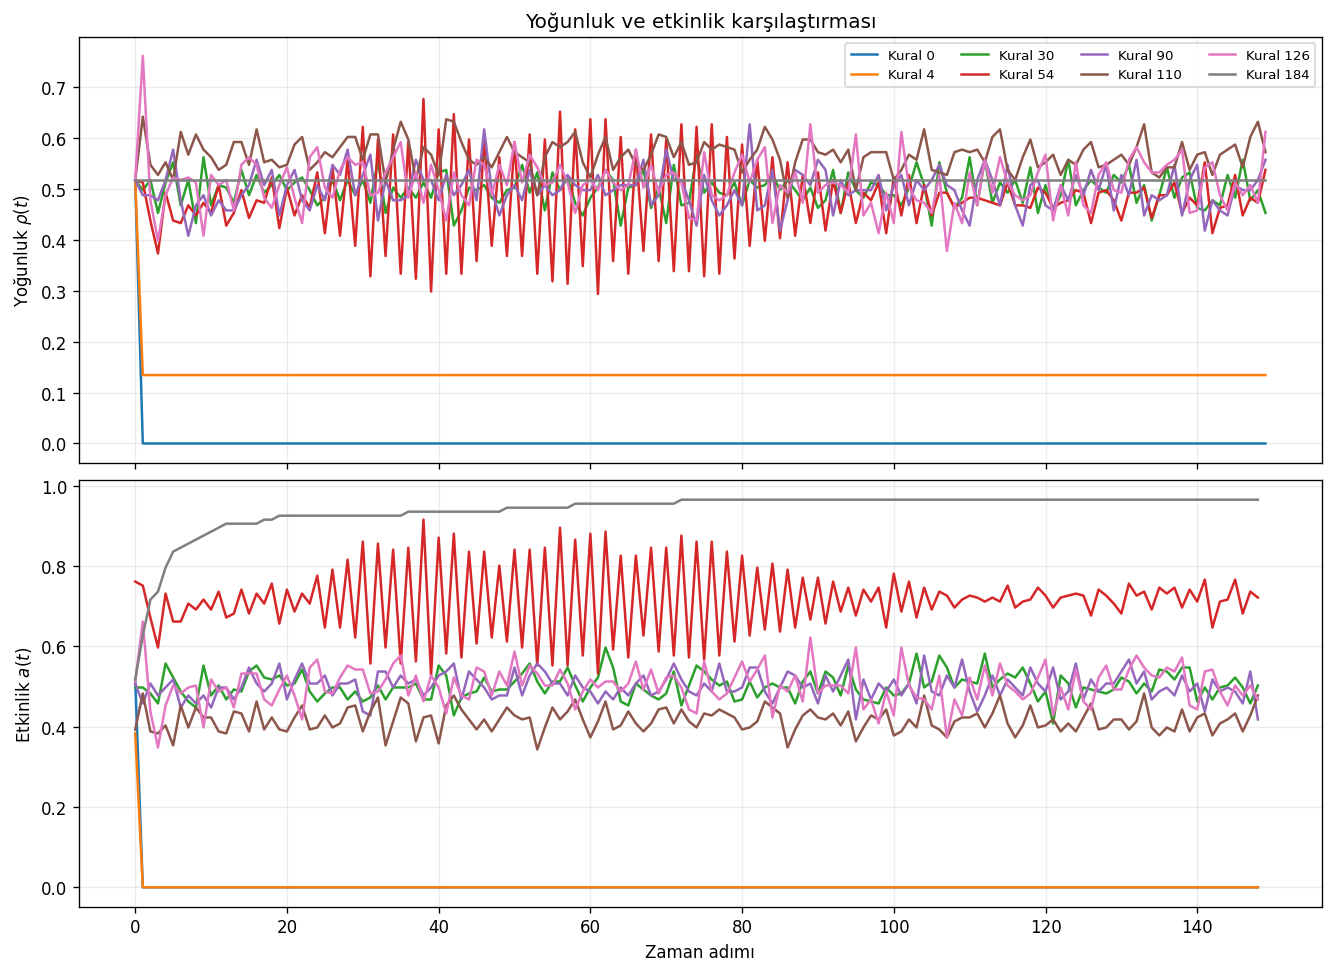

In [12]:
representative_rules = [0, 4, 30, 54, 90, 110, 126, 184]
measurement_steps = 150
measurement_initial = _random_initial_state_reference(
    201, 0.5, np.random.default_rng(42)
)

fig, (ax_density, ax_activity) = plt.subplots(
    2, 1, figsize=(11, 8), sharex=True, constrained_layout=True
)

for rule in representative_rules:
    history = simulate(measurement_initial, rule, measurement_steps)
    ax_density.plot(_density_reference(history), label=f"Kural {rule}")
    ax_activity.plot(_activity_reference(history), label=f"Kural {rule}")

ax_density.set(ylabel=r"Yoğunluk $\rho(t)$", title="Yoğunluk ve etkinlik karşılaştırması")
ax_activity.set(xlabel="Zaman adımı", ylabel=r"Etkinlik $a(t)$")
ax_density.grid(alpha=0.25)
ax_activity.grid(alpha=0.25)
ax_density.legend(ncol=4, fontsize=8)
plt.show()

### Şekli yorumla

Aşağıdaki soruları şekilden sayısal veya görsel kanıt vererek yanıtla:

1. Benzer yoğunluğa sahip fakat farklı etkinlik gösteren iki kural bul.
2. Hangi kurallar sabit veya periyodik bir davranışa yaklaşıyor gibi görünüyor?
3. Yüksek etkinlik bir kuralın mutlaka Sınıf III olduğu anlamına gelir mi?
4. Tek başına yoğunluk, Kural 30 ile Kural 110'u güvenilir biçimde ayırabilir mi?

Yanıtlarım:

> 1. Kural 90 ve Kural 30'un uzun vadeli yoğunlukları birbirine çok yakın (ikisi de $\bar\rho\approx0.50$), ama etkinlik seviyeleri farklı: Kural 90'ın etkinliği $\bar a\approx0.50$ civarında kalırken Kural 54'ün etkinliği belirgin biçimde daha yüksek, $\bar a\approx0.72$. Yani benzer yoğunluk, çok farklı bir etkinlik seviyesiyle bir arada olabiliyor.
>
> 2. Kural 0 ve Kural 4'ün etkinliği ölçüm penceresinin tamamında tam olarak sıfıra iniyor ($a(t)=0$, son 50 adımda ortalama ve standart sapma da 0); bu, sistemin sabit bir duruma kilitlendiğinin güçlü bir sayısal kanıtı. Kural 184 de etkinliğini neredeyse hiç değiştirmiyor (std $\approx 0$), ama bu kez çok yüksek bir seviyede ($\bar a\approx0.965$) sabitleniyor. Yani "sabit davranış" hem düşük hem yüksek etkinlik seviyesinde ortaya çıkabiliyor.
>
> 3. Hayır. Kural 184 bunun açık bir örneği: etkinliği neredeyse maksimuma yakın ve tamamen kararlı ($\bar a\approx0.965$, std$\approx0$), ama görüntüde kaotik bir gürültü değil, hücrelerin düzenli biçimde bir yönde kaydığı çok düzenli bir örüntü var. Yüksek etkinlik burada deterministik bir "akışı" yansıtıyor, kaosu değil.
>
> 4. Hayır, tek başına yoğunluk yeterli değil: Kural 30 ve Kural 110'un uzun vadeli yoğunlukları birbirine yakın ($\bar\rho\approx0.50$ ve $\bar\rho\approx0.56$). Ama etkinlik değerleri onları ayırıyor (Kural 30 için $\bar a\approx0.51$, Kural 110 için $\bar a\approx0.41$, üstelik Kural 110'un etkinlik eğrisi zamanla daha az dalgalanıyor: std$\approx0.028$'e karşı Kural 30'da std$\approx0.033$) ve gerçek görüntüdeki desen de farklı (Kural 30'da düzensiz, tekrarsız bir doku; Kural 110'da düzenli bir arka plan üzerinde hareket eden yerelleşmiş yapılar). Yani yoğunluk + etkinlik + görsel gözlem birlikte kullanıldığında ikisini ayırt edebiliyoruz, ama yoğunluğun tek başına yeterli olmadığı açık.

<details>
<summary>İpucu: Yoğunluk ve etkinlik neden birlikte daha yararlı?</summary>

Yoğunluk toplam dolu hücre oranını, etkinlik ise zaman içinde değişen hücre oranını ölçer. Aynı yoğunluğa sahip iki sistemden biri donmuş, diğeri hızla değişiyor olabilir. İki ölçüm birlikte kullanıldığında daha fazla bilgi taşır, yine de uzamsal düzenin tamamını göstermez.
</details>


## 8. Başlangıç koşuluna bağımlılık

Bir kuralı yalnızca tek bir başlangıç durumuyla sınıflandırmak risklidir. Şimdi aynı kuralı iki başlangıçtan çalıştıracağız:

1. merkezde tek dolu hücre;
2. $p=0.5$ yoğunluklu rastgele satır.

### Alıştırma 4

Aşağıdaki fonksiyonda iki benzetimi tamamla. Fonksiyon, iki geçmişi bir demet (`tuple`) olarak döndürmeli.

In [13]:
def compare_initial_conditions(rule_number, width, steps, seed=42):
    '''Aynı kuralı tek-tohum ve rastgele başlangıçlardan çalıştır.'''
    one_cell = single_seed(width)
    random_row = _random_initial_state_reference(
        width, 0.5, np.random.default_rng(seed)
    )

    history_single = simulate(one_cell, rule_number, steps)
    history_random = simulate(random_row, rule_number, steps)
    return history_single, history_random


In [14]:
def test_compare_initial_conditions():
    single, random = compare_initial_conditions(90, width=31, steps=12, seed=7)
    assert single.shape == (12, 31) and random.shape == (12, 31), (
        "iki geçmiş de (steps, width) biçiminde olmalı"
    )
    assert single[0].sum() == 1, "ilk geçmiş tek dolu hücreyle başlamalı"
    assert 1 < random[0].sum() < 30, "ikinci geçmiş rastgele bir satırla başlamalı"
    assert np.array_equal(single[1], update_row(single[0], 90)), (
        "tek-hücre geçmişi Kural 90 ile ilerlemeli"
    )
    assert np.array_equal(random[1], update_row(random[0], 90)), (
        "rastgele geçmiş Kural 90 ile ilerlemeli"
    )


check("Alıştırma 4 - başlangıç koşulları", test_compare_initial_conditions)

✓ Alıştırma 4 - başlangıç koşulları: geçti


### Karşılaştırma şekli

Testin geçtikten sonra aşağıdaki `simulate` çağrılarını kendi `compare_initial_conditions` fonksiyonunla değiştirmeyi dene.

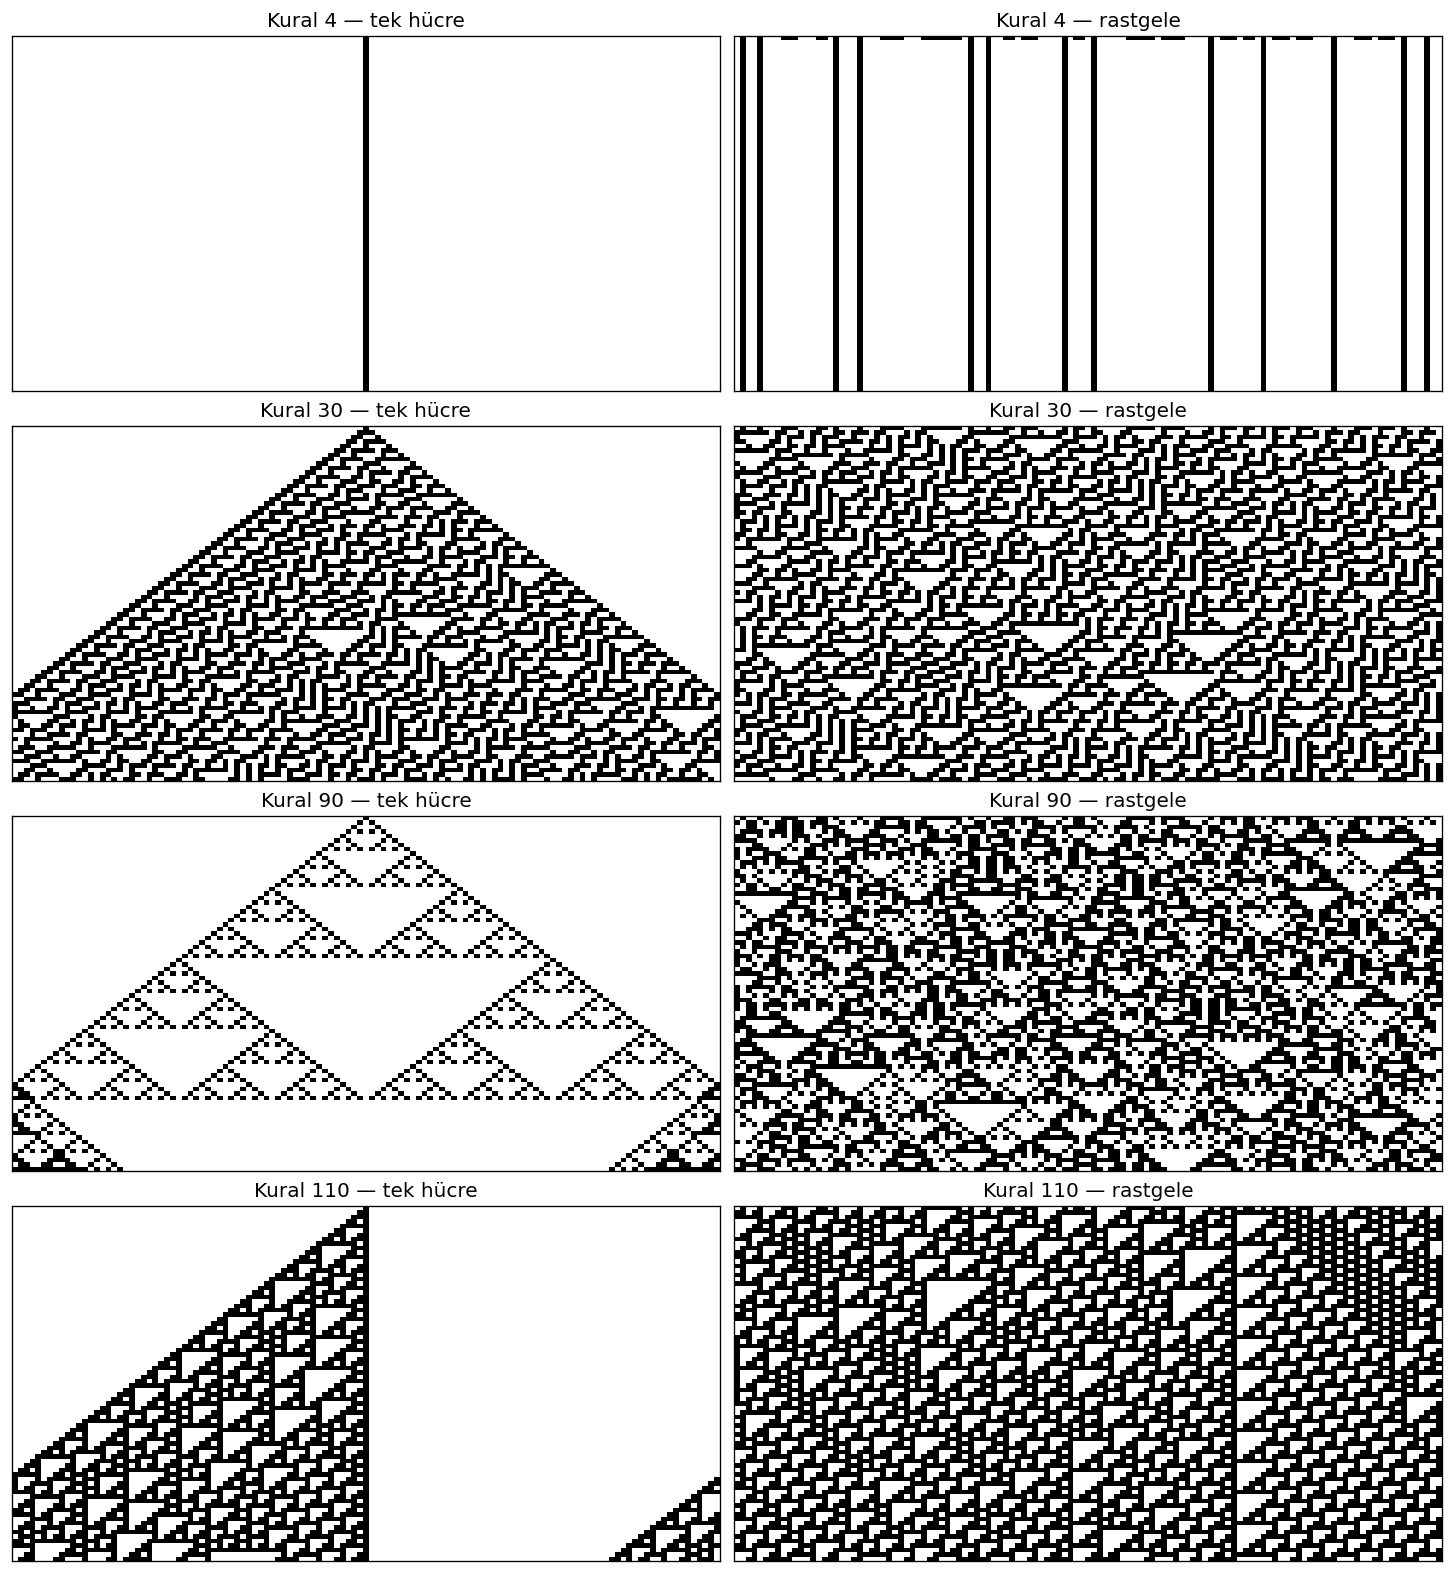

In [15]:
rules_to_compare = [4, 30, 90, 110]
comparison_width = 121
comparison_steps = 80
random_comparison_initial = _random_initial_state_reference(
    comparison_width, 0.5, np.random.default_rng(42)
)

fig, axes = plt.subplots(4, 2, figsize=(12, 13), constrained_layout=True)

for row_index, rule in enumerate(rules_to_compare):
    histories = [
        simulate(single_seed(comparison_width), rule, comparison_steps),
        simulate(random_comparison_initial, rule, comparison_steps),
    ]
    for column_index, history in enumerate(histories):
        ax = axes[row_index, column_index]
        ax.imshow(history, interpolation="nearest", aspect="auto", vmin=0, vmax=1)
        ax.set_title(
            f"Kural {rule} — " + ("tek hücre" if column_index == 0 else "rastgele")
        )
        ax.set_xticks([])
        ax.set_yticks([])

plt.show()

### Başlangıç koşulu karşılaştırmasını yorumla

Her kural için iki şeklin ortak ve farklı yönlerini yaz:

| Kural | Tek hücre başlangıcı | Rastgele başlangıç | Sınıflandırmam değişti mi? |
|---:|---|---|---|
| 4 | Tek dolu hücre neredeyse hareketsiz kalıyor, yoğunluk çok düşük düzeyde donuyor ($\bar\rho\approx0.01$) ve etkinlik sıfıra iniyor. | Dağınık birkaç hücre kalıcı olarak donuyor, yoğunluk biraz daha yüksek bir düzeyde sabitleniyor ($\bar\rho\approx0.11$), etkinlik yine sıfıra iniyor. | Hayır — ikisi de hızla donan, Sınıf I benzeri bir davranış gösteriyor; yalnızca donduğu son desen farklı. |
| 30 | Düzensiz, tekrarsız bir doku, $\bar\rho\approx0.51$, $\bar a\approx0.53$, etkinlik son 30 adımda 19/30 farklı değer alacak kadar değişken. | Yine düzensiz bir doku, $\bar\rho\approx0.50$, $\bar a\approx0.48$, benzer bir değişkenlik (17/30). | Hayır, her iki başlangıçta da düzensiz/kaotik görünüyor, sınıflandırmam değişmiyor. |
| 90 | Klasik, simetrik Sierpinski-benzeri fraktal; zaman ilerledikçe yoğunluk azalıyor ($\bar\rho\approx0.13$ son 20 adımda), etkinlik de düşüyor ($\bar a\approx0.21$, std yüksek). Görsel olarak çok düzenli/kendine benzer. | Çok daha kaba ve düzensiz bir doku, $\bar\rho\approx0.46$, $\bar a\approx0.49$ | Kural 30'a benzer bir görünüm. | **Evet**  bu en çarpıcı fark: tek hücre başlangıcında net bir fraktal (Sınıf II benzeri, nested) görürken, rastgele başlangıçta çok daha düzensiz (Sınıf III benzeri) görünüyor. |
| 110 | Düzenli/periyodik bir arka plan üzerinde az sayıda yerelleşmiş, hareketli yapı (glider-benzeri); yoğunluk orta düzeyde ($\bar\rho\approx0.33$), etkinlik orta ($\bar a\approx0.24$). Yapılar görsel olarak ayırt edilebiliyor. | Arka plan çok daha yoğun/karışık ($\bar\rho\approx0.57$, $\bar a\approx0.42$), yerelleşmiş yapılar hâlâ var ama kalabalık arka planda seçmek daha zor. | Kısmen kural aynı (Sınıf IV adayı) ama rastgele başlangıçta "temiz" glider görünümü kayboluyor, izlenim daha çok Sınıf III'e kayıyor. Bu da başlangıç koşulunun görsel izlenimi ne kadar değiştirebildiğini gösteriyor. |

<details>
<summary>Soru: Kural mı, başlangıç koşulu mu daha önemlidir?</summary>

Genel bir "biri her zaman daha önemlidir" yanıtı yoktur. Gözlenen yörünge ikisinin birleşimidir. Kontrollü bir deneyde hangisini değiştirdiğimizi açıkça söylemeliyiz.
</details>


## 9. Sınıflandırma tablosu - Ana ödev

Aşağıdaki 16 kuralı galeriden ve ölçüm grafiklerinden incele:

```python
[0, 4, 8, 18, 22, 30, 45, 54, 60, 73, 90, 94, 110, 126, 150, 184]
```

Her kural için geçici bir sınıf öner. Kararsızsan `II/IV?` gibi bir etiket kullanabilirsin, belirsizliği dürüstçe belirtmek bilimsel bir davranıştır. Kanıt sütununa yalnızca "öyle görünüyor" yazma. Tekrar, simetri, uzun-zaman yoğunluğu, etkinlik veya yerel yapı gibi gözlenebilir bir özellik belirt.

Aşağıdaki tablo, galerideki (Bölüm 4, $p=0.5$, tohum 42, genişlik 101, 80 adım) görsel izlenimimle, aynı kurulumda hesapladığım uzun vadeli (son 30 adım) ortalama yoğunluk/etkinlik sayılarını birlikte kullanıyor. Sınıflar **geçicidir**; hiçbirini otomatik bir algoritma üretmedi.

| Kural | Önerilen sınıf | Görsel kanıt | Ölçümsel kanıt | Güvenim (düşük/orta/yüksek) |
|---:|:---:|---|---|:---:|
| 0 | I | Galeri karesi tamamen boş/beyaz. | $\bar\rho\approx0.00$, $\bar a\approx0.00$ - tamamen donuk. | yüksek |
| 4 | I/II? | Neredeyse boş, birkaç izole hücre sabit kalıyor gibi görünüyor. | $\bar\rho\approx0.10$ (sabit, std$\approx0$), $\bar a\approx0.00$ — donmuş bir desende kilitleniyor. | orta-yüksek |
| 8 | I | Galeri karesi tamamen boş/beyaz. | $\bar\rho\approx0.00$, $\bar a\approx0.00$ - tamamen donuk. | yüksek |
| 18 | III? | Düzensiz, parçalı, gürültülü bir doku; tekrar eden net bir motif seçemiyorum. | $\bar\rho\approx0.24$–$0.36$ arası dalgalanıyor, $\bar a\approx0.48$–$0.55$ ve etkinlik standart sapması nispeten yüksek (0.05–0.07) — kararsız görünüyor. | orta |
| 22 | III? | Kaba dokulu, düzensiz görünen bir desen. | $\bar\rho\approx0.30$–$0.36$, $\bar a\approx0.55$ civarı, yine yüksek dalgalanma (std$\approx0.06$–$0.07$). Simülasyon süresince etkinlik yüksek kalıyor. | orta |
| 30 | III | Klasik düzensiz, tekrarsız görünümlü doku (galeri gözleminde de "düzensiz" olarak işaretlemiştim). | $\bar\rho\approx0.50$, $\bar a\approx0.51$, etkinlik sürekli dalgalı (std$\approx0.05$–$0.06$), uzun-zaman sıfıra yaklaşmıyor. | yüksek |
| 45 | III | 30'a benzer düzensiz bir doku, belki biraz daha "bloklu". | $\bar\rho\approx0.49$–$0.55$, $\bar a\approx0.49$, std$\approx0.036$ — sürekli orta-yüksek etkinlik. | orta-yüksek |
| 54 | II/IV? | Galeride en çok zorlandığım kurallardan biri: ne tamamen donuk ne tamamen gürültülü, bazı yerelleşmiş yapı ipuçları var gibi. | $\bar a\approx0.72$ ile beklediğimden daha yüksek ve simülasyon boyunca yüksek kalıyor; $\bar\rho\approx0.47$–$0.48$ orta düzeyde. Bu davranış Class III benzeri de görünebilir, ama görsel yerel yapılar Class IV olasılığını da düşündürüyor. | düşük |
| 60 | II? | Kendine benzer, katmanlı bir desen (XOR tabanlı, Pascal üçgeni benzeri) — düzenli bir kurala göre üretiliyor izlenimi veriyor. | $\bar\rho\approx0.50$, $\bar a\approx0.50$, std$\approx0.04$ — ölçüm tek başına bakıldığında Class III gibi de yorumlanabilir. Bu tam olarak yoğunluk/etkinliğin tek başına yeterli olmadığı bir durum; daha güçlü bir sonuç için yapı/simetri ölçümü gerekir. | düşük |
| 73 | II? | Küçük, tekrarlayan bloklu yerel yapılar seçiyorum; en çok zorlandığım kurallardan biri. | $\bar a\approx0.40$ orta düzeyde ve nispeten kararlı (std$\approx0.028$, diğer kurallara göre düşük) — bu bir miktar düzenliliğe işaret edebilir. $\bar\rho\approx0.42$–$0.51$. | orta |
| 90 | II (tek-tohum) / III? (rastgele) | Tek-tohum başlangıcında net bir Sierpinski-benzeri fraktal; rastgele başlangıçta çok daha düzensiz (bkz. Bölüm 8). | Tek-tohumda $\bar\rho$ zamanla düşüyor ($\approx0.13$); rastgele başlangıçta $\bar\rho\approx0.50$, $\bar a\approx0.50$. Ölçüm de başlangıca göre çok değişiyor. | düşük (başlangıca çok bağlı) |
| 94 | II | Sabit genişlikte dikey şeritler, donuk/düzenli izlenim (galeri gözleminde de böyle not etmiştim). | $\bar a\approx0.12$ ile diğer kurallara göre belirgin biçimde düşük ve std$\approx0.016$ ile kararlı — periyodik/durağan davranışla uyumlu güçlü bir sayısal kanıt. | yüksek |
| 110 | IV | Düzenli bir arka plan üzerinde hareket eden yerelleşmiş yapılar (glider-benzeri); literatürde karmaşık/"edge of chaos" davranışıyla bilinen bir kural. | $\bar a\approx0.42$ orta düzeyde (ne 0'a ne 1'e yakın), std$\approx0.043$–$0.046$ — ne tam donuk ne aşırı gürültülü bir profil, bu izlenimi destekliyor. | orta-yüksek |
| 126 | III | 30'a benzer düzensiz bir doku (bazı kaynaklarda 30'un "tümleyeni" olarak anılıyor). | $\bar\rho\approx0.51$, $\bar a\approx0.50$, std$\approx0.07$ — incelediğim kurallar arasında en yüksek dalgalanmalardan biri. | orta-yüksek |
| 150 | II? | Kendine benzer, fraktal görünümlü desen (XOR tabanlı toplamsal kural). | $\bar\rho\approx0.51$, $\bar a\approx0.48$, std$\approx0.056$ - Kural 60'takine benzer bir gerilim: ölçüm tek başına düzenli/toplamsal yapıyı ayırt etmiyor. | düşük |
| 184 | II | Rastgele başlangıçta bile belirgin, çapraz "akan" bir görünüm; tanıdığım kadarıyla trafik-akışı benzeri parçacık modeli olarak bilinen bir kural. | $\bar a\approx0.95$ ile çok yüksek ama neredeyse tamamen kararlı (std$\approx0$) — yüksek etkinliğin kaos değil, deterministik bir kaymadan geldiğine işaret ediyor. | orta |

### Sınıflandırma yönteminin sınırları

Şu soruya 5-8 cümleyle yanıt ver:

> Sonlu süreli tek bir benzetimden bir ECA kuralına kesin sınıf etiketi vermek neden zor olabilir?

> Sonlu süreli tek bir benzetimden kesin bir sınıf etiketi çıkarmak birkaç nedenle zor. Birincisi, benzetimi yalnızca 80–150 adım çalıştırıyoruz, bir kural çok daha uzun bir geçici (transient) evreden sonra farklı bir davranışa geçebilir ve biz bu geçişi hiç göremeyebiliriz. İkincisi, periyodik sınır koşulları sonlu bir genişlikte "sarma" etkisi yaratıyor: bu, sonsuz bir şeritte görülecek davranışı bozabilir. Özellikle Kural 110'daki gibi geniş yerelleşmiş yapıların genişliğe sığmadığı durumlarda. Üçüncüsü, tek bir başlangıç koşulundan elde edilen sonuç o kurala özgü olmayabilir: Bölüm 8'de gördüğümüz gibi Kural 90 tek hücre başlangıcında net bir fraktal sergilerken rastgele başlangıçta çok daha düzensiz görünüyor. Dördüncüsü, yoğunluk ve etkinlik yalnızca özet istatistikler; uzamsal düzeni (yerelleşmiş yapıların varlığı gibi) doğrudan ölçmüyorlar, bu yüzden Kural 54, 60, 73 ve 150 gibi "arada kalan" kurallarda bu iki ölçüm bile kesin bir ayrım sağlamıyor. Son olarak, Wolfram'ın dört sınıfı keskin sınırları olan matematiksel bir taksonomi değil, gözlemsel bir kılavuz; bu yüzden birçok kural sınıflar arasında bir yerde durabilir ve etiketimiz her zaman "geçici" kalmalı.


## 10. İsteğe bağlı ileri araştırma: 256 kuralın ölçüm haritası

Zamanın kalırsa her kural için geçici ilk 50 adımı atıp kalan zamanda ortalama yoğunluk ve ortalama etkinlik hesapla:

$$
\bar\rho=\frac{1}{T-50}\sum_{t=50}^{T-1}\rho(t),
\qquad
\bar a=\frac{1}{T-51}\sum_{t=50}^{T-2}a(t).
$$

Sonra 256 noktayı $(\bar\rho,\bar a)$ düzleminde çiz. Yakın noktalar mutlaka aynı görsel sınıfta mı?

Bu bölüm isteğe bağlıdır, aşağıdaki iskeleti tamamladım.

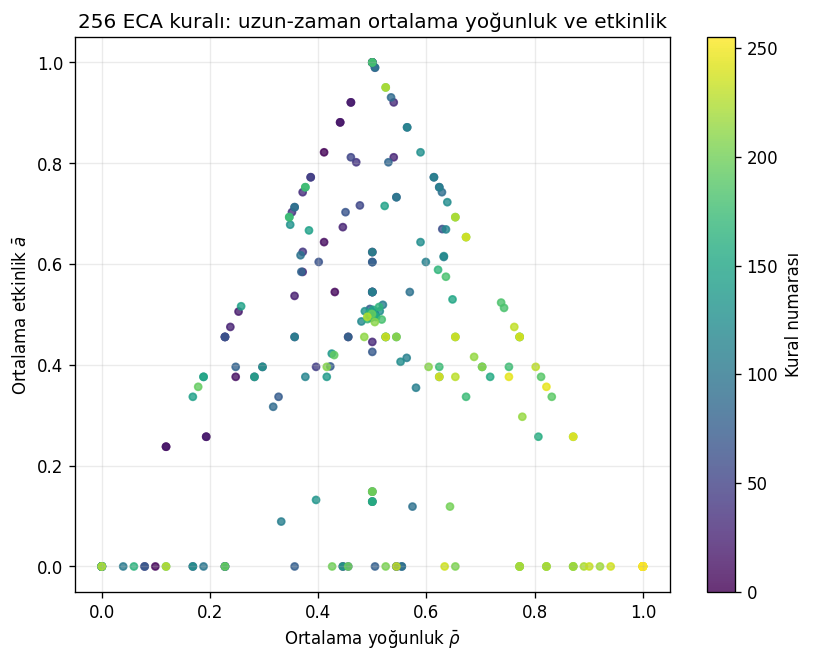

In [16]:
mean_densities = []
mean_activities = []

scatter_steps = 200
scatter_warmup = 50

for rule in range(256):
    history = simulate(gallery_initial, rule, steps=scatter_steps)
    rho = density_time_series(history)
    act = activity_time_series(history)
    mean_densities.append(rho[scatter_warmup:].mean())
    mean_activities.append(act[scatter_warmup - 1:].mean())

mean_densities = np.array(mean_densities)
mean_activities = np.array(mean_activities)

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(
    mean_densities, mean_activities, c=np.arange(256),
    cmap="viridis", s=18, alpha=0.8,
)
ax.set(
    xlabel=r"Ortalama yoğunluk $\bar\rho$",
    ylabel=r"Ortalama etkinlik $\bar a$",
    title="256 ECA kuralı: uzun-zaman ortalama yoğunluk ve etkinlik",
)
ax.grid(alpha=0.25)
cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label("Kural numarası")
plt.show()


### Saçılım grafiğini yorumla

Bu saçılım grafiği yalnızca her kural için **ortalama** yoğunluk ve **ortalama** etkinliği gösteriyor; birbirine yakın noktalar otomatik olarak aynı uzay-zaman desenine, aynı Wolfram sınıfına veya kesin bir sınıflandırmaya sahip olduğu anlamına gelmiyor. Örneğin Kural 90 ve Kural 30, rastgele başlangıçta grafikte birbirine oldukça yakın konumda ($\bar\rho\approx0.50$, $\bar a\approx0.50$ civarında), ama galeride gördüğümüz gibi Kural 90 tek tohum başlangıcında net bir fraktal sergiliyor, Kural 30 ise çok daha düzensiz görünüyor. Ortalamalar bu farkı gizliyor. Ayrıca ortalama alma işlemi zamansal bilgiyi kaybediyor: bir kuralın önce yüksek sonra düşük etkinlik göstermesiyle sürekli orta düzey etkinlik göstermesi aynı ortalamaya karşılık gelebilir, hâlbuki bunlar çok farklı davranışlardır. Bu yüzden saçılım grafiğini yalnızca kaba bir tarama/ön eleme aracı olarak, galeri ve zaman serisi grafikleriyle birlikte kullanmalıyız.


## 11. Sonuç ve haftalık kontrol noktası

### Çıkış sorusu

Aşağıdaki soruya 5-7 cümleyle yanıt ver:

> Görsel sınıflandırma, yoğunluk ve etkinlik ölçümleri birbirini nasıl tamamlar? Bunlardan herhangi biri tek başına bir hücresel otomatın davranışını eksiksiz tanımlar mı?

Yanıtım:

> Görsel sınıflandırma, galerideki her deseni bir bütün olarak görmemi sağlıyor ve yerelleşmiş yapılar (Kural 110'daki glider-benzeri hareketler gibi) ya da simetriler gibi yoğunluk/etkinlik ölçümlerinin doğrudan yakalayamadığı ayrıntıları ortaya çıkarıyor. Ama görsel izlenim öznel olabiliyor ve sonlu bir resimden "kaotik" gibi kesin bir yargıya varmak riskli. Kural 54 ve Kural 73'te olduğu gibi galeriye bakarak kararsız kalabiliyorum. Yoğunluk ve etkinlik ise öznel olmayan, tekrarlanabilir sayılar veriyor: örneğin Kural 184'ün etkinliğinin çok yüksek ($\bar a\approx0.965$) ama tamamen kararlı (std$\approx0$) olması, görüntüde klasik anlamda "kaotik" görünmeyen ama sürekli değişen bir sistemi sayısal olarak ayırt etmemi sağladı. Yine de bu iki ölçüm de uzamsal düzeni doğrudan ölçmüyor, aynı ortalama yoğunluk ve etkinliğe sahip iki kural (örneğin Kural 30 ile Kural 90'ın rastgele başlangıçtaki hâli) çok farklı görsel yapılara sahip olabiliyor. Bu yüzden bu üç yaklaşımdan (galeri, yoğunluk, etkinlik) hiçbiri tek başına bir hücresel otomatın davranışını eksiksiz tanımlamıyor; üçünü birlikte kullanmak, herhangi birinin tek başına vereceğinden daha güvenilir bir resim veriyor. Başlangıç koşuluna bağımlılığı da (Bölüm 8) hesaba katarsam, "bu kural şu sınıftandır" ifadesinin aslında her zaman zımni olarak bir başlangıç koşulu ve bir gözlem süresi varsaydığını da eklemem gerekiyor.

### Görüşmeye getirilecekler

- dört alıştırma testinin geçmesi;
- 256 kural galerisi;
- doldurulmuş 16 kural sınıflandırma tablosu;
- yoğunluk ve etkinlik karşılaştırma şekli;
- iki başlangıç koşulunu karşılaştıran şekil ve tablo;
- deneyden önceki tahminlerinle sonuçların arasındaki fark;
- tartışmak istediğin iki soru.
